In [ ]:
!pip install -U albumentations
!pip install opencv-python-headless==4.8.0.74
!pip install "numpy<2.0"

Reason for being yanked: deprecated, use 4.8.0.76
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 15.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albucore 0.0.24 requires opencv-python-headless>=4.9.0.80, but you have opencv-python-headless 4.8.0.74 which is incompatible.
albumentations 2.0.8 requires opencv-python-headless>=4.9.0.80, but you have opencv-python-headless 4.8.0.74 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 133.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing 

In [ ]:
!pip install -U albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 137.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.8.0.74
    Uninstalling opencv-python-headless-4.8.0.74:
      Successfully uninstalled opencv-python-headless-4.8.0.74
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.


In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.utils.data
import torchvision
from tqdm import tqdm
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from google.colab import drive
import albumentations as A
from albumentations.pytorch import ToTensorV2
import gc

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_DIR = "/content/drive/MyDrive/data/cubicasa"
IMG_DIR = os.path.join(DATA_DIR, "images")
MASK_DIR = os.path.join(DATA_DIR, "masks")

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

TARGET_CLASSES = {
    2: "Door",
    3: "Window"
}

NUM_CLASSES = len(TARGET_CLASSES) + 1
BATCH_SIZE = 4
EPOCHS = 30

In [ ]:
def get_train_transforms():
    return A.Compose([
        A.Resize(height=512, width=512),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.2, rotate_limit=15, p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

def get_valid_transforms():
    return A.Compose([
        A.Resize(height=512, width=512),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

In [ ]:
class CubiCasaInstanceDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, mask_dir, class_mapping, transforms=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transforms = transforms
        self.imgs = list(sorted(os.listdir(img_dir)))
        self.class_mapping = class_mapping

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        mask_path = os.path.join(self.mask_dir, self.imgs[idx])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask_semantic = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        masks = []
        labels = []
        boxes = []

        for pixel_val, class_name in self.class_mapping.items():
            class_mask = np.where(mask_semantic == pixel_val, 1, 0).astype('uint8')
            num_labels, labels_im = cv2.connectedComponents(class_mask)

            for i in range(1, num_labels):
                instance_mask = np.where(labels_im == i, 1, 0).astype('uint8')
                y_indices, x_indices = np.where(instance_mask == 1)

                if len(y_indices) == 0: continue

                xmin, xmax = np.min(x_indices), np.max(x_indices)
                ymin, ymax = np.min(y_indices), np.max(y_indices)

                if (xmax - xmin) < 5 or (ymax - ymin) < 5: continue

                h, w = img.shape[:2]
                xmin = max(0, xmin); ymin = max(0, ymin)
                xmax = min(w, xmax); ymax = min(h, ymax)

                masks.append(instance_mask)
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(list(self.class_mapping.keys()).index(pixel_val) + 1)

        if self.transforms:
            if len(boxes) > 0:
                transformed = self.transforms(image=img, masks=masks, bboxes=boxes, labels=labels)
                img = transformed['image']
                boxes = torch.as_tensor(transformed['bboxes'], dtype=torch.float32)
                labels = torch.as_tensor(transformed['labels'], dtype=torch.int64)
                masks = torch.stack([torch.as_tensor(m, dtype=torch.uint8) for m in transformed['masks']])
            else:
                transformed = self.transforms(image=img, masks=[], bboxes=[], labels=[])
                img = transformed['image']
                boxes = torch.zeros((0, 4), dtype=torch.float32)
                labels = torch.zeros((0,), dtype=torch.int64)
                masks = torch.zeros((0, 512, 512), dtype=torch.uint8)

        if len(boxes) > 0:
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            target = {
                "boxes": boxes, "labels": labels, "masks": masks,
                "image_id": torch.tensor([idx]), "area": area,
                "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64)
            }
        else:
            target = {
                "boxes": torch.zeros((0, 4), dtype=torch.float32),
                "labels": torch.zeros((0,), dtype=torch.int64),
                "masks": torch.zeros((0, 512, 512), dtype=torch.uint8),
                "image_id": torch.tensor([idx]), "area": torch.tensor([]),
                "iscrowd": torch.tensor([])
            }

        return img, target

    def __len__(self):
        return len(self.imgs)

In [ ]:
def get_model_instance_segmentation(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    return model

def collate_fn(batch):
    return tuple(zip(*batch))

In [ ]:
def subset_copy(file_list, src_img, src_mask, dst):
    os.makedirs(dst + "/images", exist_ok=True)
    os.makedirs(dst + "/masks", exist_ok=True)
    for f in file_list:
        os.system(f"cp {src_img}/{f} {dst}/images/")
        os.system(f"cp {src_mask}/{f} {dst}/masks/")

all_images = sorted(os.listdir(IMG_DIR))
split_idx = int(len(all_images) * 0.85)
train_imgs_list = all_images[:split_idx]
val_imgs_list = all_images[split_idx:]

subset_copy(train_imgs_list, IMG_DIR, MASK_DIR, "/content/train_inst")
subset_copy(val_imgs_list, IMG_DIR, MASK_DIR, "/content/val_inst")

In [ ]:
train_dataset = CubiCasaInstanceDataset(
    "/content/train_inst/images",
    "/content/train_inst/masks",
    TARGET_CLASSES,
    transforms=get_train_transforms()
)

val_dataset = CubiCasaInstanceDataset(
    "/content/val_inst/images",
    "/content/val_inst/masks",
    TARGET_CLASSES,
    transforms=get_valid_transforms()
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, collate_fn=collate_fn
)

val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=2, collate_fn=collate_fn
)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
def evaluate_accuracy_fast(model, data_loader, device, score_threshold=0.5):
    model.eval()
    total_iou = 0
    num_images = 0

    with torch.no_grad():
        for images, targets in data_loader:
            torch.cuda.empty_cache()

            images = list(img.to(device) for img in images)

            try:
                outputs = model(images)
            except RuntimeError as e:
                if "out of memory" in str(e):
                    torch.cuda.empty_cache()
                    continue
                raise e

            for i, output in enumerate(outputs):
                pred_masks = output['masks']
                pred_scores = output['scores']

                keep = pred_scores > score_threshold
                pred_masks = pred_masks[keep]

                if len(pred_masks) == 0:
                    num_images += 1
                    continue

                pred_masks = (pred_masks > 0.5).squeeze(1).cpu().float()
                pred_flat = pred_masks.view(pred_masks.size(0), -1)

                target_masks = targets[i]['masks'].cpu().float()
                if len(target_masks) == 0:
                    num_images += 1
                    continue
                target_flat = target_masks.view(target_masks.size(0), -1)

                intersection = torch.mm(pred_flat, target_flat.t())
                area_pred = pred_flat.sum(1).view(-1, 1)
                area_target = target_flat.sum(1).view(1, -1)

                union = area_pred + area_target - intersection
                iou_matrix = intersection / (union + 1e-6)

                max_ious, _ = iou_matrix.max(dim=0)
                total_iou += max_ious.mean().item()
                num_images += 1

            del images, outputs, pred_masks, target_masks

    model.train()

    if num_images == 0: return 0.0
    return (total_iou / num_images) * 100

In [ ]:
# Initialize Model
model = get_model_instance_segmentation(NUM_CLASSES)
model.to(DEVICE)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Scheduler
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

# Added 'train_acc' to history
history = {'train_loss': [], 'val_acc': [], 'train_acc': []}

print("Starting training...")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for images, targets in pbar:
        images = list(image.to(DEVICE) for image in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

        optimizer.step()

        epoch_loss += losses.item()
        pbar.set_postfix({'Loss': f"{losses.item():.4f}"})

    avg_loss = epoch_loss / len(train_loader)
    history['train_loss'].append(avg_loss)

    # Clean Memory
    del images, targets, loss_dict, losses
    torch.cuda.empty_cache()
    gc.collect()

    # --- 1. Calculate Validation Accuracy ---
    val_acc = evaluate_accuracy_fast(model, val_loader, DEVICE)
    history['val_acc'].append(val_acc)

    # --- 2. Calculate Training Accuracy (NEW BLOCK) ---
    # We only check the first 50 images to keep it fast
    subset_indices = range(min(len(train_dataset), 50))
    train_subset = torch.utils.data.Subset(train_dataset, subset_indices)
    train_subset_loader = torch.utils.data.DataLoader(
        train_subset, batch_size=1, collate_fn=collate_fn
    )
    train_acc = evaluate_accuracy_fast(model, train_subset_loader, DEVICE)
    history['train_acc'].append(train_acc)

    # Update Scheduler
    lr_scheduler.step(val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1} Summary:")
    print(f"  Avg Loss: {avg_loss:.4f}")
    print(f"  Train Acc (Subset): {train_acc:.2f}%")
    print(f"  Val Acc (Full):     {val_acc:.2f}%")
    print(f"  Current LR: {current_lr}")
    print("-" * 30)

    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), f"/content/drive/MyDrive/maskrcnn_epoch_{epoch+1}.pth")

torch.save(model.state_dict(), "/content/drive/MyDrive/final_maskrcnn_optimized.pth")

Starting training...


Epoch 1/30: 100%|██████████| 337/337 [07:24<00:00,  1.32s/it, Loss=1.1868]


Epoch 1 Summary:
  Avg Loss: 1.5238
  Train Acc (Subset): 54.47%
  Val Acc (Full):     59.97%
  Current LR: 0.0001
------------------------------


Epoch 2/30: 100%|██████████| 337/337 [07:42<00:00,  1.37s/it, Loss=1.2811]


Epoch 2 Summary:
  Avg Loss: 1.2953
  Train Acc (Subset): 53.05%
  Val Acc (Full):     58.40%
  Current LR: 0.0001
------------------------------


...

Epoch 23/30: 100%|██████████| 337/337 [07:49<00:00,  1.39s/it, Loss=0.8207]


Epoch 23 Summary:
  Avg Loss: 0.8910
  Train Acc (Subset): 67.90%
  Val Acc (Full):     67.84%
  Current LR: 2.5e-05
------------------------------


Epoch 24/30: 100%|██████████| 337/337 [07:51<00:00,  1.40s/it, Loss=0.6916]


Epoch 24 Summary:
  Avg Loss: 0.8731
  Train Acc (Subset): 67.21%
  Val Acc (Full):     68.97%
  Current LR: 2.5e-05
------------------------------


Epoch 25/30:  28%|██▊       | 93/337 [02:04<04:16,  1.05s/it, Loss=0.9101]

Unique Pixel Values in this mask: [0 1 2 3]


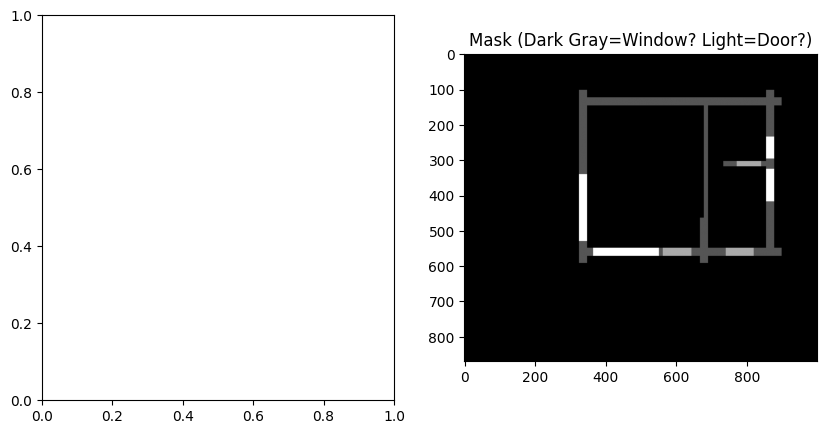

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Path to your masks
MASK_DIR = "/content/drive/MyDrive/data/cubicasa/masks"

# Get a file
mask_file = sorted(os.listdir(MASK_DIR))[5] # Pick the 5th file
mask_path = os.path.join(MASK_DIR, mask_file)
img_path = mask_path.replace("masks", "images").replace(".png", ".jpg") # Adjust extension if needed

# Load Mask
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
print(f"Unique Pixel Values in this mask: {np.unique(mask)}")

# Plot them side-by-side to compare
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
img = cv2.imread(img_path)
if img is not None:
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")

plt.subplot(1, 2, 2)
# We multiply by 50 to make the tiny pixel values (1, 2, 3) visible as shades of gray
plt.imshow(mask * 50, cmap='gray')
plt.title("Mask (Dark Gray=Window? Light=Door?)")

plt.show()

In [ ]:
import torch

# 1. Define the path to your saved model
# CHANGE THIS if your file name is different
model_path = "/content/drive/MyDrive/final_maskrcnn_optimized.pth"

print(f"Loading model from: {model_path}")

# 2. Re-initialize the model architecture
# We must create a "blank" model with the same settings (num_classes)
loaded_model = get_model_instance_segmentation(NUM_CLASSES)
loaded_model.to(DEVICE)

# 3. Load the weights
if os.path.exists(model_path):
    checkpoint = torch.load(model_path, map_location=DEVICE)
    loaded_model.load_state_dict(checkpoint)
    print("Model weights loaded successfully.")
else:
    print(f"Error: File not found at {model_path}")

# 4. Calculate Accuracy
print("Calculating validation accuracy... (This may take 1-2 minutes)")

# Ensure you have 'val_loader' and 'evaluate_accuracy_fast' defined from previous cells
if 'val_loader' in globals() and 'evaluate_accuracy_fast' in globals():
    final_acc = evaluate_accuracy_fast(loaded_model, val_loader, DEVICE)
    print("-" * 30)
    print(f"Final Model Accuracy (mIoU): {final_acc:.2f}%")
    print("-" * 30)
else:
    print("Error: 'val_loader' or 'evaluate_accuracy_fast' is missing.")
    print("Please re-run the 'Dataset Initialization' and 'Accuracy Function' cells.")

Loading model from: /content/drive/MyDrive/final_maskrcnn_optimized.pth
Model weights loaded successfully.
Calculating validation accuracy... (This may take 1-2 minutes)
------------------------------
Final Model Accuracy (mIoU): 68.63%
------------------------------


In [ ]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- CONFIGURATION ---
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
NUM_CLASSES = 3  # 0=BG, 1=Window, 2=Door (Must match training!)

# Map model class IDs back to names
# Note: In training we mapped pixel 2->1 and pixel 3->2.
# So Model ID 1 is Window, Model ID 2 is Door.
CLASS_NAMES = {
    1: "Door",
    2: "Window"
}

# Define Model Architecture (Must be exact same as training)
def get_model_instance_segmentation(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    return model

def load_model(model_path):
    print(f"Loading model from: {model_path}")
    model = get_model_instance_segmentation(NUM_CLASSES)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model

In [ ]:
def predict_and_plot(model, img_path, score_threshold=0.5):
    # 1. Load Image
    if not os.path.exists(img_path):
        print(f"Error: Image not found at {img_path}")
        return

    original_img = cv2.imread(img_path)
    if original_img is None:
        print("Error: Could not read image.")
        return

    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Convert to Tensor (0-1 range)
    img_tensor = torchvision.transforms.functional.to_tensor(original_img).to(DEVICE)

    # 2. Run Inference
    with torch.no_grad():
        prediction = model([img_tensor])[0]

    # 3. Filter Results
    boxes = prediction['boxes'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()
    scores = prediction['scores'].cpu().numpy()
    masks = prediction['masks'].cpu().numpy()

    # Create a copy for drawing
    draw_img = original_img.copy()

    # Generate colors (Green for Window, Red for Door)
    colors = {1: (0, 255, 0), 2: (255, 0, 0)}

    print(f"--- Detections (Threshold: {score_threshold}) ---")

    found_any = False

    # We will accumulate all masks on this layer
    mask_overlay = np.zeros_like(draw_img, dtype=np.uint8)
    alpha_mask = np.zeros((draw_img.shape[0], draw_img.shape[1]), dtype=np.uint8)

    for i, score in enumerate(scores):
        if score > score_threshold:
            found_any = True
            box = boxes[i].astype(int)
            label_id = labels[i]
            label_name = CLASS_NAMES.get(label_id, "Unknown")
            mask = masks[i, 0]

            print(f"Found {label_name} with confidence {score:.2f}")

            # Get Color
            color = colors.get(label_id, (255, 255, 255))

            # 1. Draw Bounding Box
            cv2.rectangle(draw_img, (box[0], box[1]), (box[2], box[3]), color, 2)

            # 2. Draw Label
            text = f"{label_name}: {score:.2f}"
            cv2.putText(draw_img, text, (box[0], box[1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

            # 3. Prepare Mask for Blending
            # Binarize the mask (soft probability -> hard 0 or 1)
            mask_binary = mask > 0.5

            # Add this instance's color to the overlay layer
            mask_overlay[mask_binary] = color
            # Mark these pixels as "needs blending"
            alpha_mask[mask_binary] = 1

    # 4. Perform Robust Blending (Fixes the Shape Mismatch)
    if found_any:
        # Create a blended version of the WHOLE image
        # 0.6 * Original + 0.4 * Overlay
        blended = cv2.addWeighted(draw_img, 0.6, mask_overlay, 0.4, 0)

        # Only copy the blended pixels where masks actually exist
        # This keeps the background perfectly clear
        mask_indices = alpha_mask > 0
        draw_img[mask_indices] = blended[mask_indices]
    else:
        print("No objects detected above threshold.")

    # 5. Show Result
    plt.figure(figsize=(12, 12))
    plt.imshow(draw_img)
    plt.axis('off')
    plt.title(f"Predictions (Threshold: {score_threshold})")
    plt.show()

Loading model from: /content/drive/MyDrive/final_maskrcnn_optimized.pth
--- Detections (Threshold: 0.5) ---
Found Window with confidence 1.00
Found Door with confidence 1.00
Found Door with confidence 1.00
Found Door with confidence 0.99
Found Window with confidence 0.99
Found Door with confidence 0.99
Found Door with confidence 0.99
Found Door with confidence 0.99
Found Door with confidence 0.99
Found Door with confidence 0.99
Found Window with confidence 0.99
Found Window with confidence 0.99
Found Door with confidence 0.99
Found Door with confidence 0.99
Found Window with confidence 0.98
Found Window with confidence 0.98
Found Window with confidence 0.98


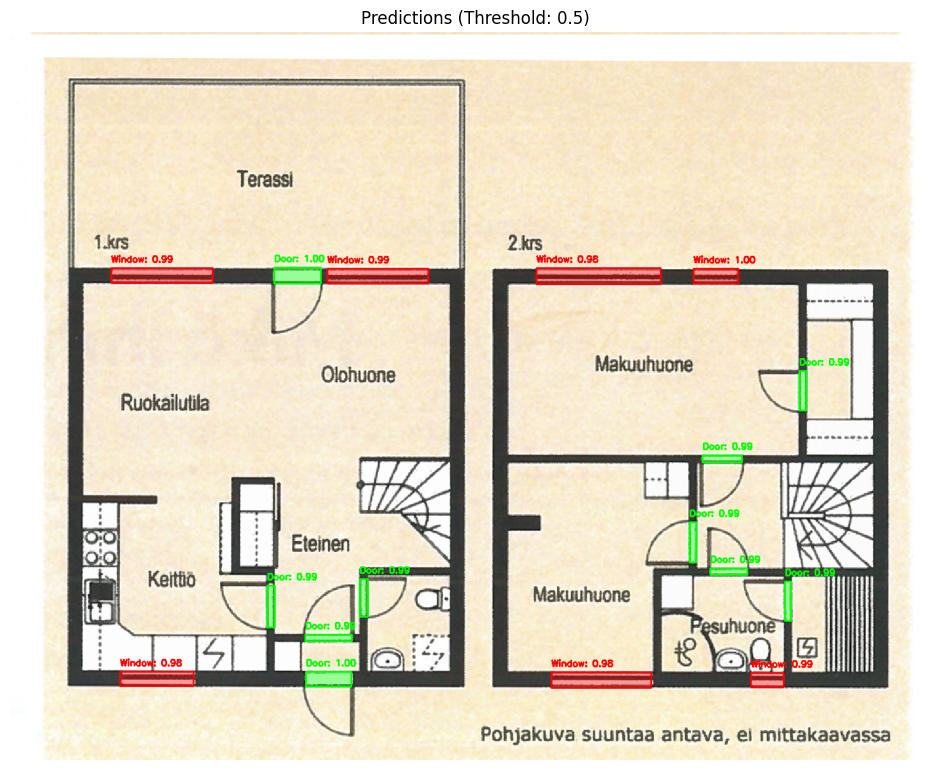

In [ ]:
# 1. Path to your trained model
MODEL_PATH = "/content/drive/MyDrive/final_maskrcnn_optimized.pth"

# 2. Path to the image you want to test
# Upload an image to colab or use one from your validation set
TEST_IMAGE_PATH = "/content/F1_scaled.png"
# OR upload manually and use: "/content/my_test_image.jpg"

# Load and Predict
if os.path.exists(MODEL_PATH):
    loaded_model = load_model(MODEL_PATH)

    # Run prediction (adjust score_threshold if you miss detections)
    predict_and_plot(loaded_model, TEST_IMAGE_PATH, score_threshold=0.5)
else:
    print(f"Model file not found at {MODEL_PATH}")

Model loaded successfully.

--- UPLOAD AN IMAGE TO HIGHLIGHT ---


Saving F1_scaled.png to F1_scaled (3).png

Processing F1_scaled (3).png...
Detected 21 items.


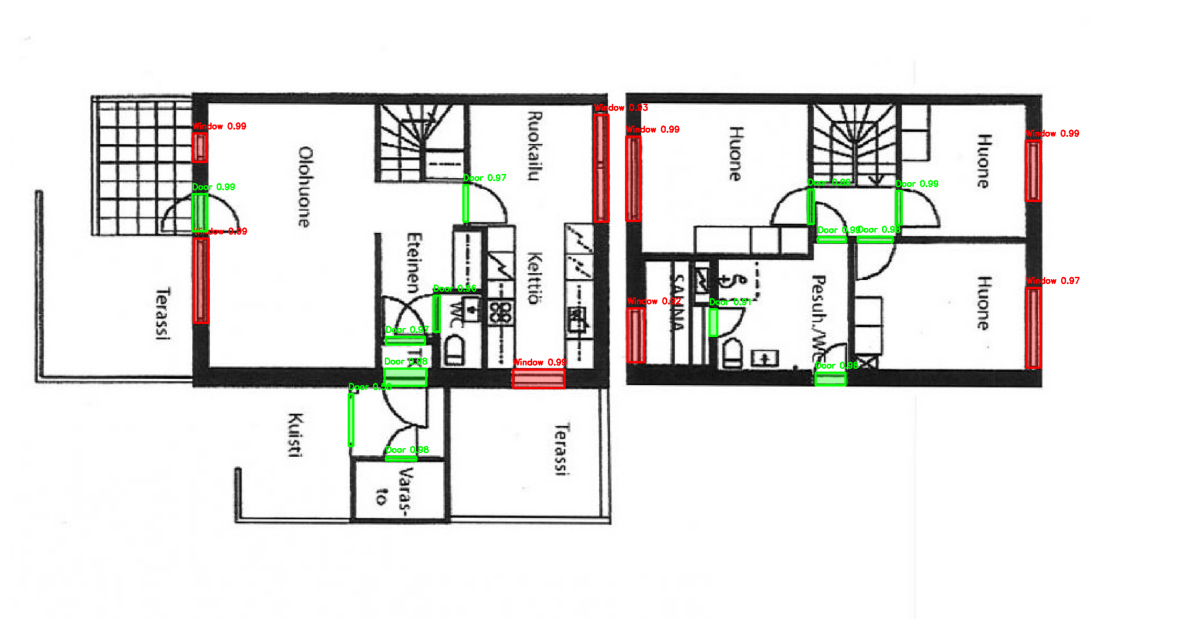

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from google.colab import files
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import os

# --- 1. SETUP (Load Model) ---
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
NUM_CLASSES = 3 # BG + Window + Door
CLASS_NAMES = {1: "Door", 2: "Window"}
MODEL_PATH = "/content/drive/MyDrive/final_maskrcnn_optimized.pth" # Or 'epoch_30.pth'

def get_model(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    return model

# Load model once
if os.path.exists(MODEL_PATH):
    model = get_model(NUM_CLASSES)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    print("Model loaded successfully.")
else:
    print(f"Error: Model not found at {MODEL_PATH}")
    model = None

# --- 2. THE ROBUST VISUALIZATION FUNCTION ---
def highlight_instances(img_path, model):
    # Load Image
    img = cv2.imread(img_path)
    if img is None: return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Predict
    tensor_img = torchvision.transforms.functional.to_tensor(img).to(DEVICE)
    with torch.no_grad():
        prediction = model([tensor_img])[0]

    # Filter by Score > 0.5
    scores = prediction['scores'].cpu().numpy()
    keep = scores > 0.5

    boxes = prediction['boxes'].cpu().numpy()[keep]
    labels = prediction['labels'].cpu().numpy()[keep]
    masks = prediction['masks'].cpu().numpy()[keep]
    final_scores = scores[keep]

    # Prepare Overlay
    overlay = np.zeros_like(img, dtype=np.uint8)
    alpha_mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)

    colors = {1: (0, 255, 0), 2: (255, 0, 0)} # Green=Window, Red=Door

    print(f"Detected {len(boxes)} items.")

    for i, box in enumerate(boxes):
        label_id = labels[i]
        score = final_scores[i]
        color = colors.get(label_id, (255, 255, 255))
        label_text = CLASS_NAMES.get(label_id, 'Unknown')

        # 1. Draw Box
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

        # 2. Draw Label
        cv2.putText(img, f"{label_text} {score:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        # 3. Prepare Mask
        mask = masks[i, 0] > 0.5
        overlay[mask] = color
        alpha_mask[mask] = 1

    # 4. Blend Image + Overlay
    # Only blend pixels where we actually have a mask
    if len(boxes) > 0:
        blended = cv2.addWeighted(img, 0.65, overlay, 0.35, 0)
        mask_indices = alpha_mask > 0
        img[mask_indices] = blended[mask_indices]

    # Display
    plt.figure(figsize=(15, 15))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# --- 3. UPLOAD AND RUN ---
if model is not None:
    print("\n--- UPLOAD AN IMAGE TO HIGHLIGHT ---")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"\nProcessing {filename}...")
        highlight_instances(filename, model)